In [1]:
# Classification Problem

from sklearn.datasets import make_classification
import numpy as np
import matplotlib.pyplot as plt


%matplotlib widget
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation
from sklearn.linear_model import LogisticRegression

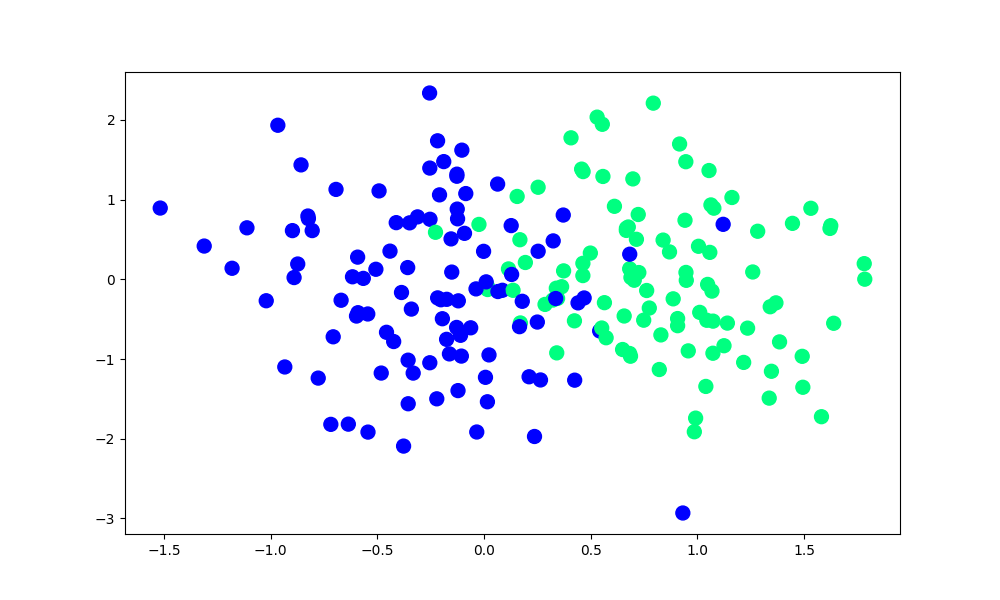

In [2]:
# Generate Data

X, y = make_classification(n_samples=200, n_features=2, n_informative=1,n_redundant=0, n_classes=2, n_clusters_per_class=1, random_state=5,hypercube=False,class_sep=5)

# Plot Data
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

In [3]:
# Heaviside Step Function -> x < 0 -> 0  OR  x > 0 -> 1

def step(z):
    return 1 if z>0 else 0

# Perceptron function
def perceptron(X,y):
    
    # Add column at position 0 with value 1 -> To implement dot product
    X = np.insert(X,0,1,axis=1)
    
    # Generate weight and assign value 1 to all the coefficient
    # Initiate Coefficient
    weights = np.ones(X.shape[1])
    
    # Learning Rate
    lr = 0.1
    
    # Epoch -> 1000
    for i in range(1000):
        
        # Pick Random Row
        j = np.random.randint(0,100)
        
        # Predict OutPut in Binary Form (0,1)
        y_hat = step(np.dot(X[j],weights))
        
        # Calculate New Weight
        weights = weights + lr*(y[j]-y_hat)*X[j]
        
    # return New Weight
    return weights[0],weights[1:]

In [4]:
intercept_,coef_ = perceptron(X,y)

# To Plot Line ->  need Slope and y_Intercept

# Slope
m = -(coef_[0]/coef_[1])

# Intercept
b = -(intercept_/coef_[1])

(-3.0, 2.0)

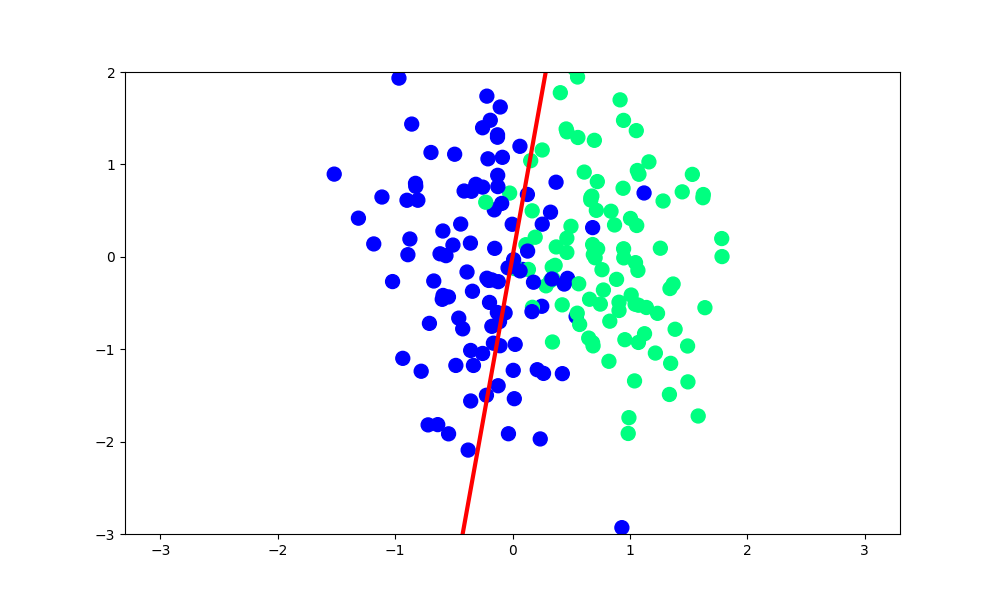

In [5]:
x_input = np.linspace(-3,3,100)
y_input = m*x_input + b


plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

# Observation -> 
# Decision Boundary is Successfully Plotted

Animation

In [6]:
def perceptron(X,y):
    
    m = []
    b = []
    
    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1
    
    for i in range(200):
        j = np.random.randint(0,100)
        y_hat = step(np.dot(X[j],weights))
        weights = weights + lr*(y[j]-y_hat)*X[j]
        
        m.append(-(weights[1]/weights[2]))
        b.append(-(weights[0]/weights[2]))
        
    return m,b
m,b = perceptron(X,y)

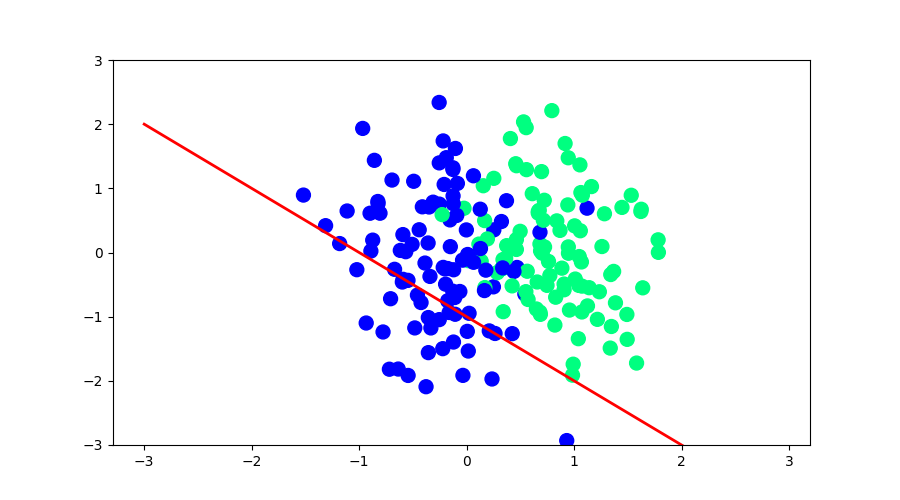

In [7]:
fig, ax = plt.subplots(figsize=(9,5))

x_i = np.arange(-3, 3, 0.1)
y_i = x_i*m[0] +b[0]
ax.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
line, = ax.plot(x_i, x_i*m[0] +b[0] , 'r-', linewidth=2)
plt.ylim(-3,3)
def update(i):
    label = 'epoch {0}'.format(i + 1)
    line.set_ydata(x_i*m[i] + b[i])
    ax.set_xlabel(label)

anim = FuncAnimation(fig, update, repeat=True, frames=200, interval=100)

Actual Logistic Regression Works Differently -> check While Implementing

(-3.0, 2.0)

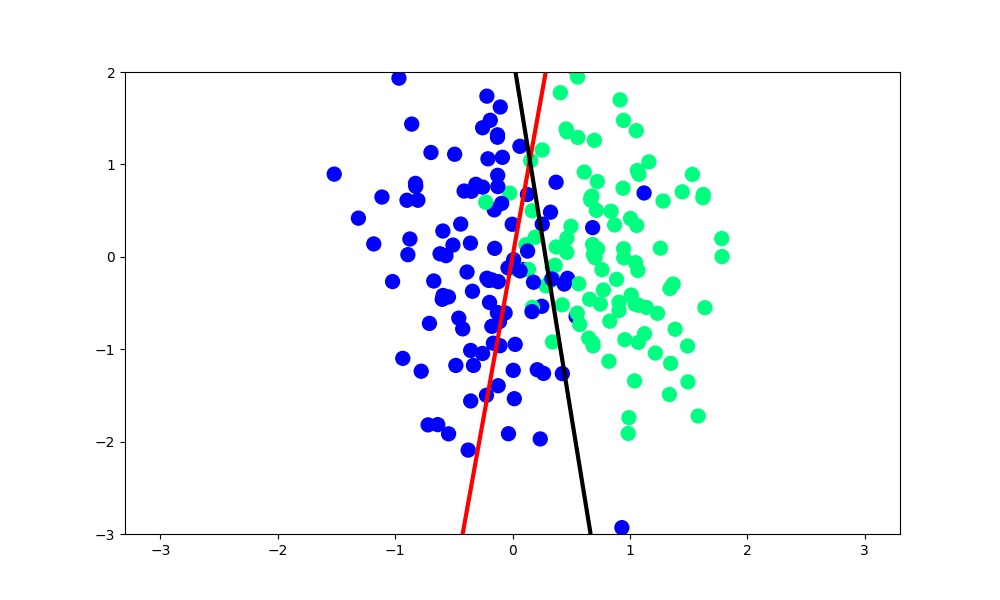

In [8]:
# Create Object
lr = LogisticRegression()

# Fit
lr.fit(X,y)

# Train Model
LogisticRegression()

# Generate Slope and Intercept
m = -(lr.coef_[0][0]/lr.coef_[0][1])
b = -(lr.intercept_/lr.coef_[0][1])

# Plot The Graph
x_input1 = np.linspace(-3,3,100)
y_input1 = m*x_input + b

plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input1,y_input1,color='black',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

# Difference is Visible Between Actual and Our Simple Approach

In [9]:
# If Seperation is High between the Class 
# My Code Stops once the Condition is Met
# Logistic Regression class Improves itself Event after finding the correct line. 
# -> To Predict Accurately for Future DataSet  -> Less Error On new Data